# 05 — Previsão de Demanda
## LH Nautical | Forecasting de Faturamento

**Objetivo:** Projetar o faturamento dos próximos meses usando modelos estatísticos,
apoiando decisões de compra de estoque e planejamento financeiro.

**Modelos implementados:**

| Modelo           | Complexidade | Melhor para                      |
|------------------|-------------|----------------------------------|
| Media Movel      | Baixa       | Baseline simples, comunicacao    |
| Regressao Linear | Baixa       | Capturar tendencia de crescimento|

> **Nota de honestidade analitica:** Com 2 anos de histórico e 49 clientes únicos,
> os resultados são orientações direcionais. Recomenda-se Prophet quando
> houver >= 3 anos de dados mensais.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.forecasting.demand_forecast import (
    media_movel, regressao_linear_forecast, gerar_relatorio_previsao
)

plt.style.use('seaborn-v0_8-whitegrid')
AZUL_LH    = '#1565C0'
VERDE_LH   = '#2E7D32'
LARANJA_LH = '#E65100'
CINZA_LH   = '#546E7A'

fato = pd.read_parquet('../data/gold/fato_vendas.parquet')
print(f'Dados carregados: {len(fato):,} transacoes')

Dados carregados: 9,895 transacoes


---
## 1. Série Temporal de Referência

In [2]:
fato_ok = fato.copy()
fato_ok['periodo'] = fato_ok['data_venda'].dt.to_period('M')

serie = fato_ok.groupby('periodo')['receita_liquida'].sum()

print('Serie mensal de receita (R$ milhoes):')
for p, v in serie.items():
    print(f'  {p}  R$ {v/1e6:.2f}M')

print(f'\nMedia mensal  : R$ {serie.mean()/1e6:.2f}M')
print(f'Desvio padrao : R$ {serie.std()/1e6:.2f}M')
print(f'Coef. variacao: {serie.std()/serie.mean()*100:.1f}%')

Serie mensal de receita (R$ milhoes):
  2023-01  R$ 106.81M
  2023-02  R$ 101.33M
  2023-03  R$ 106.88M
  2023-04  R$ 106.53M
  2023-05  R$ 108.86M
  2023-06  R$ 98.21M
  2023-07  R$ 93.79M
  2023-08  R$ 109.52M
  2023-09  R$ 103.84M
  2023-10  R$ 102.36M
  2023-11  R$ 121.45M
  2023-12  R$ 129.24M
  2024-01  R$ 100.63M
  2024-02  R$ 122.63M
  2024-03  R$ 108.85M
  2024-04  R$ 100.31M
  2024-05  R$ 95.78M
  2024-06  R$ 99.83M
  2024-07  R$ 113.05M
  2024-08  R$ 118.91M
  2024-09  R$ 108.67M
  2024-10  R$ 127.58M
  2024-11  R$ 123.46M
  2024-12  R$ 101.74M

Media mensal  : R$ 108.76M
Desvio padrao : R$ 10.15M
Coef. variacao: 9.3%


---
## 2. Modelo 1 — Média Móvel

Usa a média dos últimos N meses como previsão.
- **Vantagem:** Fácil de explicar para stakeholders
- **Limitação:** Não captura tendência ou sazonalidade

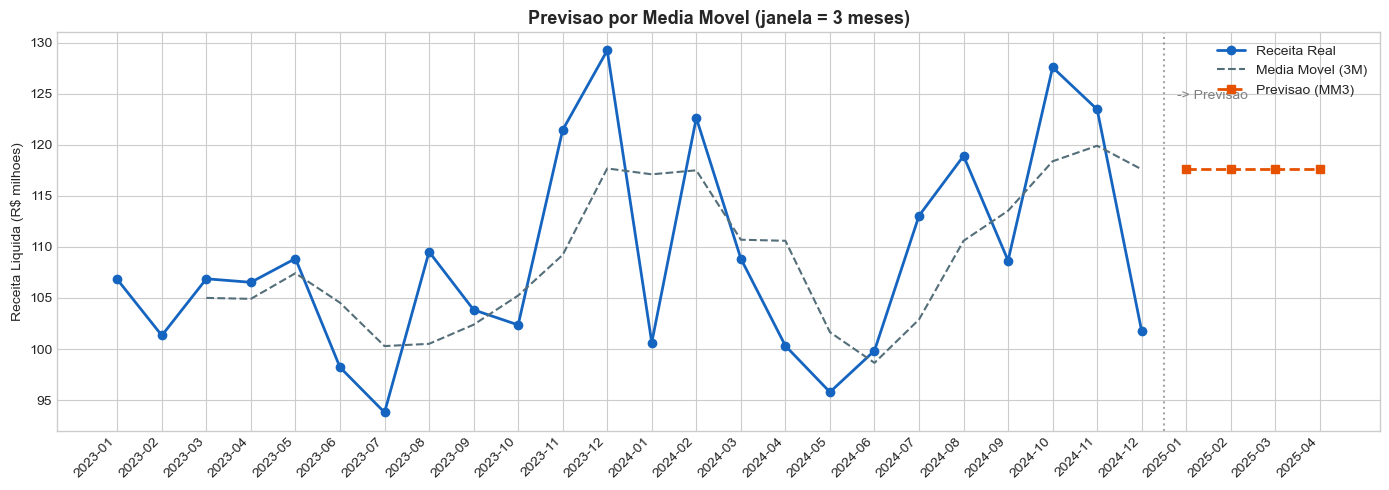


Previsoes (Media Movel 3M):


,periodo,receita_prevista_R$
24,2025-01,1.175931e+08
25,2025-02,1.175931e+08
26,2025-03,1.175931e+08
27,2025-04,1.175931e+08


In [3]:
mm3 = media_movel(fato, janela=3, periodos_futuros=4)

hist = mm3[mm3['receita_real'].notna()].copy()
prev = mm3[mm3['previsao'].notna()].copy()

# Converte Period para string para plotagem
hist['periodo_str'] = hist['periodo'].astype(str)
prev['periodo_str'] = prev['periodo'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

x_hist = range(len(hist))
x_prev = range(len(hist), len(hist) + len(prev))

ax.plot(list(x_hist), hist['receita_real'] / 1e6,
        color=AZUL_LH, marker='o', linewidth=2, label='Receita Real')
ax.plot(list(x_hist), hist['media_movel'] / 1e6,
        color=CINZA_LH, linewidth=1.5, linestyle='--', label='Media Movel (3M)')
ax.plot(list(x_prev), prev['previsao'] / 1e6,
        color=LARANJA_LH, marker='s', linewidth=2, linestyle='--', label='Previsao (MM3)')

ax.axvline(x=len(hist) - 0.5, color='gray', linestyle=':', alpha=0.7)
ax.text(len(hist) - 0.2, ax.get_ylim()[1] * 0.95, '-> Previsao', color='gray', fontsize=10)

# Eixo x com labels
todos_x  = list(x_hist) + list(x_prev)
todos_lb = list(hist['periodo_str']) + list(prev['periodo_str'])
ax.set_xticks(todos_x)
ax.set_xticklabels(todos_lb, rotation=45, ha='right')

ax.set_title('Previsao por Media Movel (janela = 3 meses)', fontweight='bold', fontsize=13)
ax.set_ylabel('Receita Liquida (R$ milhoes)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nPrevisoes (Media Movel 3M):')
display(prev[['periodo_str','previsao']].rename(
    columns={'periodo_str': 'periodo', 'previsao': 'receita_prevista_R$'}
))

---
## 3. Modelo 2 — Regressão Linear

Ajusta uma reta à série temporal, capturando a tendência geral.
- **Vantagem:** Captura direção do crescimento
- **Limitação:** Assume crescimento linear constante (não sazonal)

In [4]:
rl_df, metricas = regressao_linear_forecast(fato, periodos_futuros=6)

print('=== Metricas do Modelo de Regressao Linear ===')
for k, v in metricas.items():
    print(f'  {k:30}: {v}')

=== Metricas do Modelo de Regressao Linear ===
  coeficiente_angular           : 455155.43
  intercepto                    : 103527358.87
  mae                           : 7786149.66
  rmse                          : 9420250.13
  r2                            : 0.1006
  interpretacao                 : A receita cresce R$ 455155.43 por mês em média.


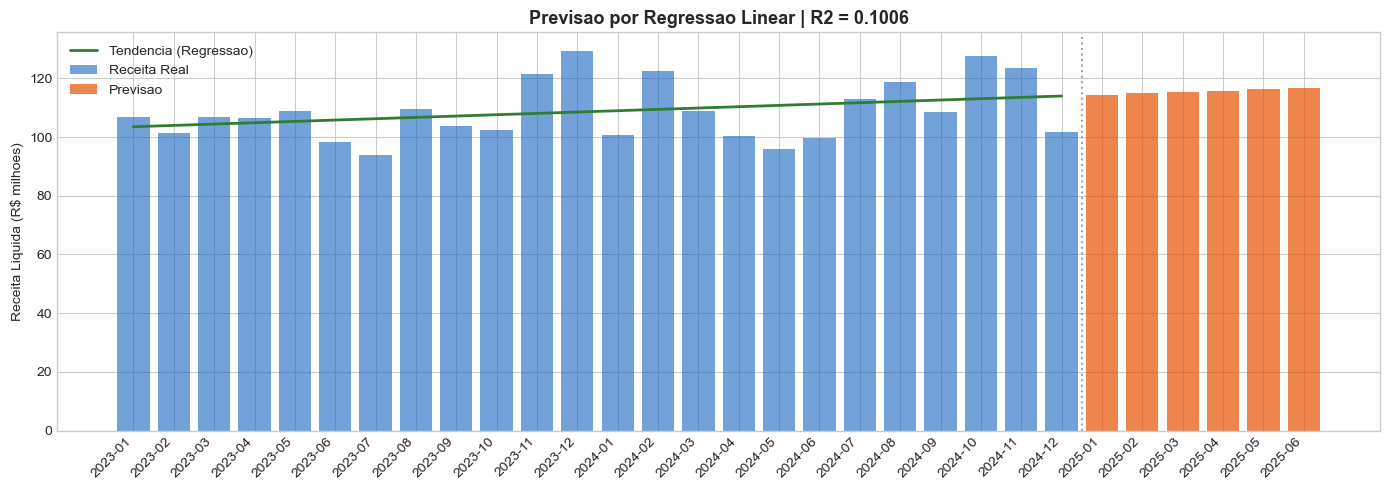


Previsoes (Regressao Linear):


,periodo,receita_prevista_R$
24,2025-01,1.144511e+08
25,2025-02,1.149062e+08
26,2025-03,1.153614e+08
27,2025-04,1.158166e+08
28,2025-05,1.162717e+08
29,2025-06,1.167269e+08


In [5]:
hist_rl = rl_df[rl_df['tipo'] == 'historico'].copy()
prev_rl = rl_df[rl_df['tipo'] == 'previsao'].copy()

hist_rl['periodo_str'] = hist_rl['periodo'].astype(str)
prev_rl['periodo_str'] = prev_rl['periodo'].astype(str)

x_h = range(len(hist_rl))
x_p = range(len(hist_rl), len(hist_rl) + len(prev_rl))

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(list(x_h), hist_rl['receita_real'] / 1e6, color=AZUL_LH, alpha=0.6, label='Receita Real')
ax.plot(list(x_h), hist_rl['ajuste_modelo'] / 1e6,
        color=VERDE_LH, linewidth=2, label='Tendencia (Regressao)')
ax.bar(list(x_p), prev_rl['ajuste_modelo'] / 1e6,
       color=LARANJA_LH, alpha=0.7, label='Previsao')

ax.axvline(x=len(hist_rl) - 0.5, color='gray', linestyle=':', alpha=0.7)

todos_x  = list(x_h) + list(x_p)
todos_lb = list(hist_rl['periodo_str']) + list(prev_rl['periodo_str'])
ax.set_xticks(todos_x)
ax.set_xticklabels(todos_lb, rotation=45, ha='right')

ax.set_title(f'Previsao por Regressao Linear | R2 = {metricas["r2"]}', fontweight='bold', fontsize=13)
ax.set_ylabel('Receita Liquida (R$ milhoes)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nPrevisoes (Regressao Linear):')
display(prev_rl[['periodo_str','ajuste_modelo']].rename(
    columns={'periodo_str': 'periodo', 'ajuste_modelo': 'receita_prevista_R$'}
))

---
## 4. Relatório Consolidado

In [6]:
gerar_relatorio_previsao(fato)


  RELATÓRIO DE PREVISÃO DE DEMANDA — LH Nautical

[Modelo 1] Média Móvel (janela = 3 meses)
----------------------------------------
  2025-01 -> R$ 117,593,100.17
  2025-02 -> R$ 117,593,100.17
  2025-03 -> R$ 117,593,100.17

[Modelo 2] Regressão Linear
  R² = 0.1006 | MAE = R$ 7,786,149.66
  Tendência: A receita cresce R$ 455155.43 por mês em média.
----------------------------------------
  2025-01 -> R$ 114,451,089.11
  2025-02 -> R$ 114,906,244.54
  2025-03 -> R$ 115,361,399.96
  2025-04 -> R$ 115,816,555.39
  2025-05 -> R$ 116,271,710.82
  2025-06 -> R$ 116,726,866.24

[Aviso] Com 2 anos de histórico, use estas previsões como
  orientação direcional, não como números exatos.
  Próximo passo recomendado: implementar Prophet ou ARIMA
  quando houver >= 3 anos de dados mensais.



---
## 5. Metodologia e Próximos Passos

### Limitações atuais
| Limitação             | Impacto                                           |
|-----------------------|---------------------------------------------------|
| 2 anos de histórico   | Série curta, padrões sazonais não confirmaveis    |
| 49 clientes únicos    | Variabilidade alta, R² baixo (~0.10)              |
| Sem variáveis externas| Câmbio, combustível, sazonalidade náutica         |

### Evolução recomendada
```
Com >= 3 anos e 500+ transacoes mensais:
  -> Prophet (Meta): sazonalidade multipla + feriados
  -> SARIMA: para series com sazonalidade confirmada
  -> XGBoost com features de calendario e variaveis externas
```

> **Próximo passo:** `06_recomendacao.ipynb` — sistema de recomendação de produtos.